# Size Distribution Exploration

This notebook analyzes coffee bag size distributions and evaluates how
bulk bag sizes may affect recommendation rankings.

Key goal:
Understand whether bulk pricing could bias price-per-ounce comparisons.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/processed/products_clean.csv")

products = pd.read_csv(DATA_PATH)
products.head()

,roaster,product_name,origin,roast_type,size,price,hearts,total_reviews,heart_percentage,decaf,blend,available_ground,single_origin,url,has_reviews,price_numeric,size_oz,price_per_oz,product_key
0,Ladro Roasting,Diablo,Unspecified,Dark Roast,12oz,20.98,446,574,77.7,False,True,True,False,/products/diablo,True,20.98,12,1.75,Ladro Roasting | Diablo
1,Ladro Roasting,Diablo,Unspecified,Dark Roast,80oz,92.13,446,574,77.7,False,True,True,False,/products/diablo,True,92.13,80,1.15,Ladro Roasting | Diablo
2,Tony's Coffee,Cafe Carmelita,Unspecified,Medium Roast,12oz,12.32,370,493,75.1,False,True,True,False,/products/cafe-carmelita,True,12.32,12,1.03,Tony's Coffee | Cafe Carmelita
3,Tony's Coffee,Cafe Carmelita,Unspecified,Medium Roast,24oz,25.20,370,493,75.1,False,True,True,False,/products/cafe-carmelita,True,25.20,24,1.05,Tony's Coffee | Cafe Carmelita
4,Tony's Coffee,Cafe Carmelita,Unspecified,Medium Roast,80oz,63.00,370,493,75.1,False,True,True,False,/products/cafe-carmelita,True,63.00,80,0.79,Tony's Coffee | Cafe Carmelita


In [3]:
print("Shape:", products.shape)
print("\nColumns:")
print(products.columns.tolist())

print("\nMissing values:")
print(products.isna().sum().sort_values(ascending=False))

Shape: (248, 19)

Columns:
['roaster', 'product_name', 'origin', 'roast_type', 'size', 'price', 'hearts', 'total_reviews', 'heart_percentage', 'decaf', 'blend', 'available_ground', 'single_origin', 'url', 'has_reviews', 'price_numeric', 'size_oz', 'price_per_oz', 'product_key']

Missing values:
roaster             0
blend               0
price_per_oz        0
size_oz             0
price_numeric       0
has_reviews         0
url                 0
single_origin       0
available_ground    0
decaf               0
product_name        0
heart_percentage    0
total_reviews       0
hearts              0
price               0
size                0
roast_type          0
origin              0
product_key         0
dtype: int64


In [4]:
key_cols = ["roaster", "product_name", "size", "size_oz", "price_numeric", "price_per_oz"]

products[key_cols].head(10)

,roaster,product_name,size,size_oz,price_numeric,price_per_oz
0,Ladro Roasting,Diablo,12oz,12,20.98,1.75
1,Ladro Roasting,Diablo,80oz,80,92.13,1.15
2,Tony's Coffee,Cafe Carmelita,12oz,12,12.32,1.03
3,Tony's Coffee,Cafe Carmelita,24oz,24,25.20,1.05
4,Tony's Coffee,Cafe Carmelita,80oz,80,63.00,0.79
5,Stamp Act Coffee,Milk Money - Seasonal Espresso,12oz,12,15.30,1.28
6,Stamp Act Coffee,Milk Money - Seasonal Espresso,32oz,32,41.40,1.29
7,Stamp Act Coffee,Milk Money - Seasonal Espresso,80oz,80,99.45,1.24
8,Blossom Coffee Roasters,Ethiopia - Ardi - Natural,32oz,32,40.50,1.27
9,Blossom Coffee Roasters,Ethiopia - Ardi - Natural,80oz,80,94.50,1.18


In [5]:
products["product_key"] = (
    products["roaster"].astype(str).str.strip() + " | " +
    products["product_name"].astype(str).str.strip()
)

products[["product_key", "size", "size_oz"]].head()

,product_key,size,size_oz
0,Ladro Roasting | Diablo,12oz,12
1,Ladro Roasting | Diablo,80oz,80
2,Tony's Coffee | Cafe Carmelita,12oz,12
3,Tony's Coffee | Cafe Carmelita,24oz,24
4,Tony's Coffee | Cafe Carmelita,80oz,80


In [6]:
products["size_oz"].describe()

count    248.000000
mean      37.266129
std       29.498263
min       10.000000
25%       12.000000
50%       32.000000
75%       80.000000
max       80.000000
Name: size_oz, dtype: float64

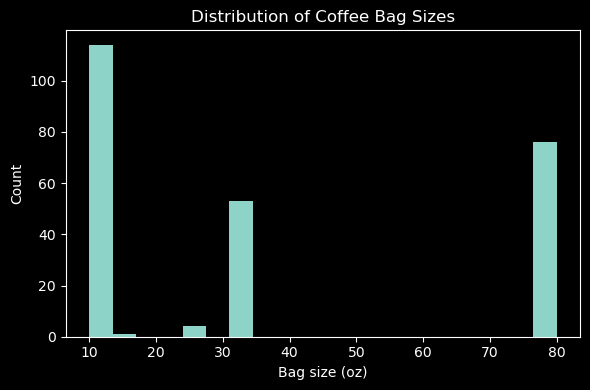

In [7]:
plt.style.use("dark_background")

plt.figure(figsize=(6, 4))
plt.hist(products["size_oz"].dropna(), bins=20)
plt.xlabel("Bag size (oz)")
plt.ylabel("Count")
plt.title("Distribution of Coffee Bag Sizes")
plt.tight_layout()
plt.show()

In [8]:
def classify_size_segment(size_oz):
    if pd.isna(size_oz):
        return "unknown"
    if size_oz < 12:
        return "small"
    if 12 <= size_oz <= 16:
        return "standard"
    if size_oz > 16:
        return "bulk"
    return "unknown"

products["size_segment"] = products["size_oz"].apply(classify_size_segment)

products["size_segment"].value_counts(dropna=False)

size_segment
bulk        133
standard    108
small         7
Name: count, dtype: int64

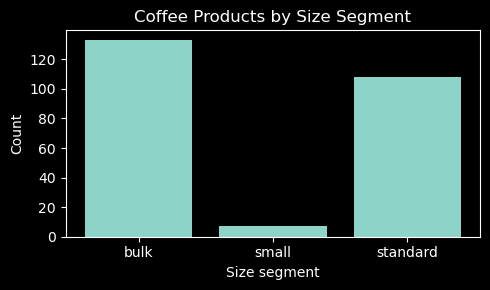

In [9]:
segment_counts = products["size_segment"].value_counts().sort_index()

plt.figure(figsize=(5, 3))
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel("Size segment")
plt.ylabel("Count")
plt.title("Coffee Products by Size Segment")
plt.tight_layout()
plt.show()

In [10]:
sizes_per_product = (
    products.groupby("product_key")["size_oz"]
    .nunique()
    .sort_values(ascending=False)
)

sizes_per_product.describe()

count    117.000000
mean       2.111111
std        0.838490
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: size_oz, dtype: float64

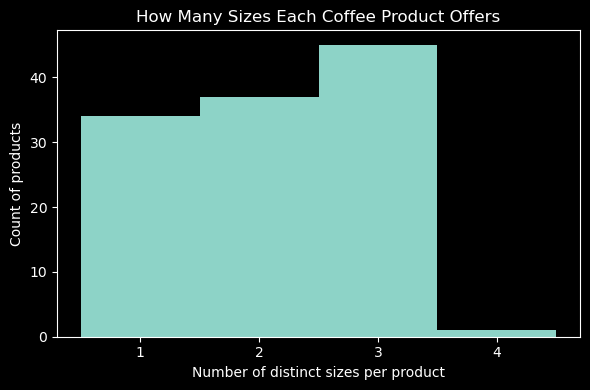

In [11]:
plt.figure(figsize=(6, 4))
plt.hist(sizes_per_product, bins=range(1, int(sizes_per_product.max()) + 2), align="left")

plt.xticks(range(1, int(sizes_per_product.max()) + 1))

plt.xlabel("Number of distinct sizes per product")
plt.ylabel("Count of products")
plt.title("How Many Sizes Each Coffee Product Offers")
plt.tight_layout()
plt.show()

In [12]:
product_segments = (
    products.groupby("product_key")["size_segment"]
    .apply(lambda x: set(x))
    .reset_index(name="segment_set")
)

product_segments["has_bulk"] = product_segments["segment_set"].apply(lambda s: "bulk" in s)
product_segments["has_standard"] = product_segments["segment_set"].apply(lambda s: "standard" in s)
product_segments["has_small"] = product_segments["segment_set"].apply(lambda s: "small" in s)

product_segments.head()

,product_key,segment_set,has_bulk,has_standard,has_small
0,Anchorhead Coffee | Colombia Cauca Cosurca,"{bulk, small}",True,False,True
1,Anchorhead Coffee | Costa Rica El Cedral,"{bulk, small}",True,False,True
2,Anchorhead Coffee | Decaf Colombia Excelso,"{bulk, small}",True,False,True
3,Anchorhead Coffee | Leviathan (Espresso Blend),"{bulk, small}",True,False,True
4,Anchorhead Coffee | Megalodon Blend,"{bulk, small}",True,False,True


In [13]:
bulk_summary = pd.DataFrame({
    "total_products": [len(product_segments)],
    "products_with_bulk": [product_segments["has_bulk"].sum()],
    "bulk_and_standard": [((product_segments["has_bulk"]) & (product_segments["has_standard"])).sum()],
    "bulk_without_standard": [((product_segments["has_bulk"]) & (~product_segments["has_standard"])).sum()],
})

bulk_summary

,total_products,products_with_bulk,bulk_and_standard,bulk_without_standard
0,117,83,73,10


In [14]:
products_with_bulk = product_segments["has_bulk"].sum()
bulk_and_standard = ((product_segments["has_bulk"]) & (product_segments["has_standard"])).sum()
bulk_without_standard = ((product_segments["has_bulk"]) & (~product_segments["has_standard"])).sum()

if products_with_bulk > 0:
    print(f"Products with bulk sizes: {products_with_bulk}")
    print(f"Bulk products that also have a standard size: {bulk_and_standard} ({bulk_and_standard / products_with_bulk:.1%})")
    print(f"Bulk-only (no standard size): {bulk_without_standard} ({bulk_without_standard / products_with_bulk:.1%})")
else:
    print("No bulk products found.")

Products with bulk sizes: 83
Bulk products that also have a standard size: 73 (88.0%)
Bulk-only (no standard size): 10 (12.0%)


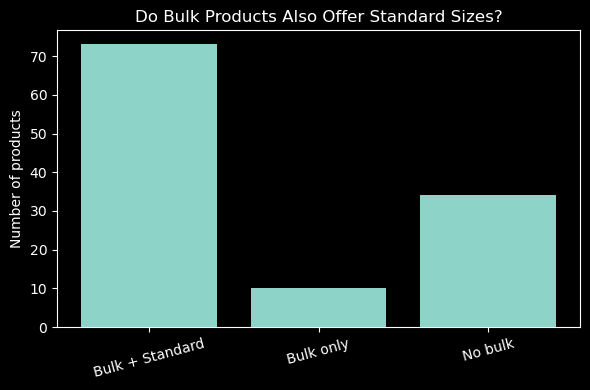

In [15]:
overlap_counts = pd.Series({
    "Bulk + Standard": ((product_segments["has_bulk"]) & (product_segments["has_standard"])).sum(),
    "Bulk only": ((product_segments["has_bulk"]) & (~product_segments["has_standard"])).sum(),
    "No bulk": (~product_segments["has_bulk"]).sum(),
})

plt.figure(figsize=(6, 4))
plt.bar(overlap_counts.index, overlap_counts.values)
plt.ylabel("Number of products")
plt.title("Do Bulk Products Also Offer Standard Sizes?")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
bulk_only_keys = product_segments.loc[
    (product_segments["has_bulk"]) & (~product_segments["has_standard"]),
    "product_key"
]

bulk_only_products = products[products["product_key"].isin(bulk_only_keys)].sort_values(
    ["product_key", "size_oz"]
)

bulk_only_products[["product_key", "size", "size_oz", "price_numeric", "price_per_oz"]].head(30)

,product_key,size,size_oz,price_numeric,price_per_oz
237,Anchorhead Coffee | Colombia Cauca Cosurca,10oz,10,21.60,2.16
238,Anchorhead Coffee | Colombia Cauca Cosurca,32oz,32,58.50,1.83
89,Anchorhead Coffee | Costa Rica El Cedral,10oz,10,21.60,2.16
90,Anchorhead Coffee | Costa Rica El Cedral,32oz,32,58.50,1.83
148,Anchorhead Coffee | Decaf Colombia Excelso,10oz,10,13.50,1.35
149,Anchorhead Coffee | Decaf Colombia Excelso,32oz,32,36.00,1.12
94,Anchorhead Coffee | Leviathan (Espresso Blend),10oz,10,13.50,1.35
95,Anchorhead Coffee | Leviathan (Espresso Blend),32oz,32,36.00,1.12
201,Anchorhead Coffee | Megalodon Blend,10oz,10,18.90,1.89
202,Anchorhead Coffee | Megalodon Blend,32oz,32,51.08,1.60


In [17]:
price_summary = (
    products.groupby("size_segment")["price_per_oz"]
    .describe()
)

price_summary

,count,mean,std,min,25%,50%,75%,max
size_segment,,,,,,,,
bulk,133.0,1.295263,0.315368,0.73,1.07,1.24,1.54,2.08
small,7.0,1.774286,0.408202,1.35,1.35,1.89,2.16,2.16
standard,108.0,1.510093,0.290403,1.03,1.28,1.43,1.75,2.21


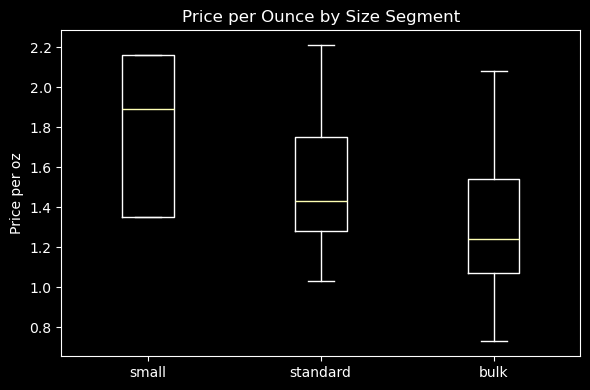

In [18]:
plot_data = [
    products.loc[products["size_segment"] == "small", "price_per_oz"].dropna(),
    products.loc[products["size_segment"] == "standard", "price_per_oz"].dropna(),
    products.loc[products["size_segment"] == "bulk", "price_per_oz"].dropna(),
]

plt.figure(figsize=(6, 4))
plt.boxplot(plot_data, tick_labels=["small", "standard", "bulk"])
plt.ylabel("Price per oz")
plt.title("Price per Ounce by Size Segment")
plt.tight_layout()
plt.show()